# Отчёт по трансформеру-прогнозисту

Прогноз спроса на день вперёд (статья: GenAI-модуль, вход F Алг. 5). Обучение: `python -m training.forecaster.train`, чекпойнт → `artifacts/modules/forecaster/`.

Датасет и структура входа — в `dataset_report.ipynb`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "generate_demand.py").exists():
            return candidate
    raise RuntimeError("project root not found (data/generate_demand.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core import config
from core.config import Weather
from data.generate_demand import DEMAND_DIR, load_demand
from training.forecaster.model import WINDOW, build_features, make_windows

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

arrays, manifest = load_demand(DEMAND_DIR)
demand = arrays["demand"]
n_series, n_days = demand.shape
split = manifest["split"]

import torch

from training.config import FORECASTER_PATH
from training.forecaster.model import load_forecaster

model = load_forecaster(FORECASTER_PATH)
checkpoint = torch.load(FORECASTER_PATH, map_location="cpu", weights_only=True)
n_params = sum(p.numel() for p in model.parameters())

print(f"checkpoint: {FORECASTER_PATH}")
print(
    f"d_model={checkpoint['d_model']}  heads={checkpoint['nhead']}  "
    f"layers={checkpoint['num_layers']}  window={checkpoint['window']}  "
    f"params={n_params:,}"
)
same = checkpoint["dataset_sha256"] == manifest["dataset_sha256"]
print(f"dataset match: {'OK' if same else 'MISMATCH — чекпойнт с другого датасета'}")

checkpoint: /home/twisted/Code/Multi-Agent Framework/artifacts/modules/forecaster/forecaster.pt
d_model=64  heads=4  layers=2  window=28  params=69,569
dataset match: OK


## Качество на тестовом сплите

Против наивных базлайнов; `oracle_floor` — неустранимый шум генератора. `% извлечённого сигнала` = какую долю разрыва last_value → oracle закрыл трансформер.

In [2]:
features = build_features(arrays)
t_start, t_end = split["test"]
lo = max(t_start, WINDOW)
x, y = make_windows(features, t_start, t_end)
with torch.no_grad():
    pred = np.concatenate([
        model(torch.as_tensor(x[i : i + 1024])).numpy()
        for i in range(0, len(x), 1024)
    ])

scale = config.INVENTORY_DEMAND_MEAN
d = demand / scale
rows = {
    "transformer": pred,
    "last_value": d[:, lo - 1 : t_end - 1].reshape(-1),
    "seasonal_naive_t-7": d[:, lo - 7 : t_end - 7].reshape(-1),
    "oracle_floor": (arrays["demand_mean"] / scale)[:, lo:t_end].reshape(-1),
}
event_day = (arrays["event_multiplier"][:, lo:t_end] > 1.0).reshape(-1)

table = pd.DataFrame({
    name: {
        "mae": float(np.abs(p - y).mean()),
        "mae@event": float(np.abs(p[event_day] - y[event_day]).mean()),
    }
    for name, p in rows.items()
}).T
display(table.round(4))

mae = table["mae"]
extracted = (mae["last_value"] - mae["transformer"]) / (
    mae["last_value"] - mae["oracle_floor"]
)
print(f"извлечено предсказуемого сигнала: {extracted:.1%}")

,mae,mae@event
transformer,0.1344,0.8309
last_value,0.3468,0.8860
seasonal_naive_t-7,0.3638,1.1879
oracle_floor,0.0994,0.1919


извлечено предсказуемого сигнала: 85.8%


## Прогноз против факта

Последние 100 дней тестового сплита, series 0.

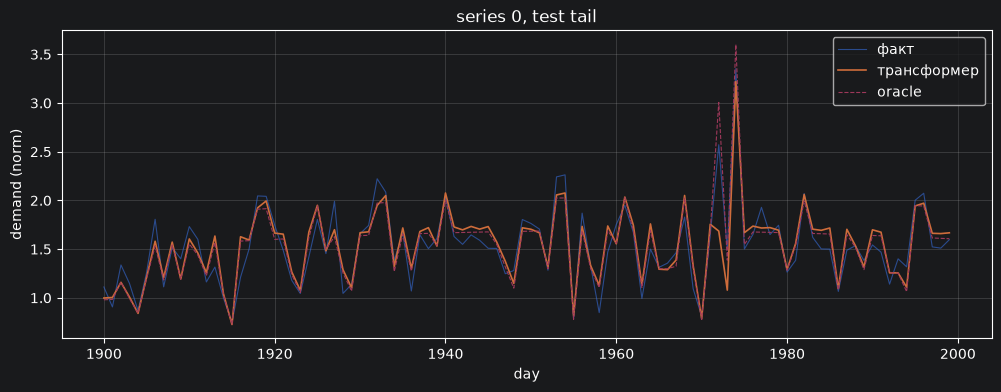

In [3]:
s, days = 0, 100
n_test = t_end - lo
pred_2d = pred.reshape(n_series, n_test)
t = np.arange(t_end - days, t_end)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, demand[s, t[0]:t_end] / scale, lw=0.8, alpha=0.6, label="факт")
ax.plot(t, pred_2d[s, -days:], lw=1.2, label="трансформер")
ax.plot(t, arrays["demand_mean"][s, t[0]:t_end] / scale, lw=0.8, ls="--",
        label="oracle")
ax.set(xlabel="day", ylabel="demand (norm)", title=f"series {s}, test tail")
ax.legend()
plt.show()

## Разбор ошибок

MAE по дню недели, погоде и event-дням: где модель теряет точность.

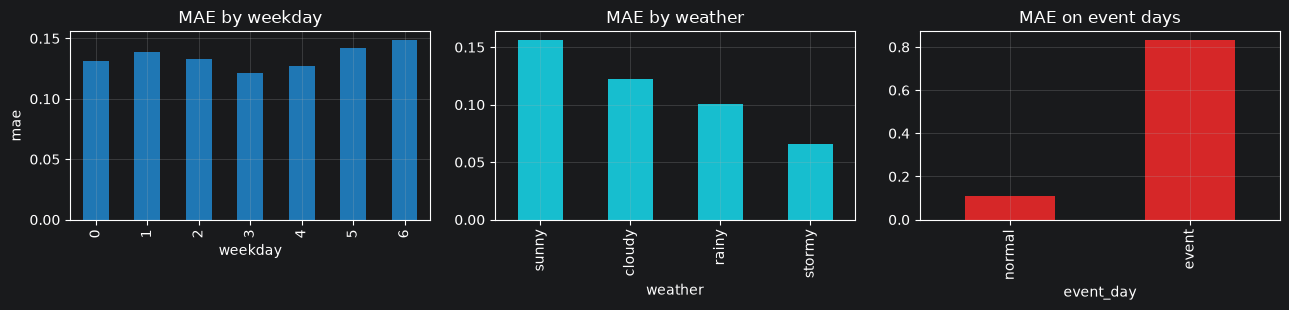

In [4]:
err = np.abs(pred_2d - y.reshape(n_series, n_test))
edf = pd.DataFrame({
    "err": err.reshape(-1),
    "weekday": arrays["weekday"][:, lo:t_end].reshape(-1),
    "weather": arrays["weather"][:, lo:t_end].reshape(-1),
    "event_day": event_day,
})
weather_names = dict(enumerate(w.value for w in Weather))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
edf.groupby("weekday")["err"].mean().plot.bar(ax=axes[0], color="tab:blue")
axes[0].set(title="MAE by weekday", ylabel="mae")
edf.groupby("weather")["err"].mean().rename(index=weather_names).plot.bar(
    ax=axes[1], color="tab:cyan"
)
axes[1].set(title="MAE by weather")
edf.groupby("event_day")["err"].mean().rename(
    index={False: "normal", True: "event"}
).plot.bar(ax=axes[2], color="tab:red")
axes[2].set(title="MAE on event days")
fig.tight_layout()
plt.show()

## Прогноз в среде

Среда заполняет `demand_forecast`: без чекпойнта — заглушкой (скользящее среднее истории), с флагом `--forecaster` — трансформером. Сравнение точности заполнения против реализованного спроса следующего дня, замороженные агенты, одинаковый сид.

In [5]:
from env.training_env import ColdChainTrainingEnv
from training.config import build_agents, env_config

N_EPISODES = 5


def forecast_errors(forecaster) -> list[float]:
    env = ColdChainTrainingEnv(env_config(123, [], forecaster))
    agents = build_agents(env, [])
    errors = []
    for _ in range(N_EPISODES):
        obs, _ = env.reset()
        done = False
        while not done:
            forecast = env._state.demand_forecast
            actions = {a: agents[a].act(obs[a], explore=False) for a in obs}
            obs, _, term, trunc, _ = env.step(actions)
            realized = env._state.demand_today
            errors.append(abs(forecast - realized) / scale)
            done = term["__all__"] or trunc["__all__"]
    return errors


stub_err = forecast_errors(None)
tf_err = forecast_errors(FORECASTER_PATH)
pd.DataFrame({
    "mae (norm)": [float(np.mean(stub_err)), float(np.mean(tf_err))],
}, index=["заглушка", "трансформер"]).round(4)

,mae (norm)
заглушка,0.5085
трансформер,0.1548
